# Milestone 1 Pre-processing

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
from datetime import datetime
import matplotlib.cm as cm
import seaborn as sns

In [126]:
def nan_percentage_plot(df):
    df_missing_val = df.isnull().sum()[df.isnull().sum() > 0].reset_index(name='missing')
    df_missing_val['percentage_missing'] = df_missing_val['missing'] / df.shape[0] *100

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(
        df_missing_val['index'],
        df_missing_val['percentage_missing'],
        edgecolor='white',
        linewidth=0.8,
        width=0.6
    )

    ax.set_xlabel('Column name', fontsize=12)
    ax.set_ylabel('% of NaNs', fontsize=12)
    ax.set_title('% of NaNs by Column', fontsize=14, fontweight='bold')

    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## 1) Pre-processing

### 1.2) ATP Matches Single

In [178]:
# ATP Tour Matches
files = [f for f in glob.glob('datasets/tennis_atp/atp_matches_*.csv')
         if re.search(r'atp_matches_\d{4}\.csv$', f)]

df_atp_matches = pd.concat(
    [pd.read_csv(f, parse_dates=['tourney_date'], date_format="%Y%m%d") for f in files],
    ignore_index=True)

df_atp_matches['tourney_date'] = pd.to_datetime(df_atp_matches['tourney_date'], errors='coerce')

df_atp_matches.to_csv("datasets/clean_datasets/all_atp_matches.csv")


In [179]:
df_atp_matches.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,300,105453,2.0,NaN,Kei Nishikori,R,178.0,JPN,29.0,106421,4.0,NaN,Daniil Medvedev,R,198.0,RUS,22.8,6-4 3-6 6-2,3,F,124.0,3.0,3.0,77.0,44.0,31.0,17.0,13.0,3.0,6.0,8.0,6.0,100.0,54.0,34.0,20.0,14.0,10.0,15.0,9.0,3590.0,16.0,1977.0
1,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,299,106421,4.0,NaN,Daniil Medvedev,R,198.0,RUS,22.8,104542,NaN,PR,Jo-Wilfried Tsonga,R,188.0,FRA,33.7,7-6(6) 6-2,3,SF,82.0,10.0,1.0,52.0,33.0,28.0,14.0,10.0,0.0,1.0,17.0,2.0,77.0,52.0,36.0,7.0,10.0,10.0,13.0,16.0,1977.0,239.0,200.0
2,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,298,105453,2.0,NaN,Kei Nishikori,R,178.0,JPN,29.0,104871,NaN,NaN,Jeremy Chardy,R,188.0,FRA,31.8,6-2 6-2,3,SF,66.0,2.0,2.0,47.0,33.0,26.0,9.0,8.0,2.0,2.0,10.0,3.0,46.0,27.0,15.0,6.0,8.0,1.0,5.0,9.0,3590.0,40.0,1050.0
3,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,297,104542,NaN,PR,Jo-Wilfried Tsonga,R,188.0,FRA,33.7,200282,7.0,NaN,Alex De Minaur,R,183.0,AUS,19.8,6-4 7-6(2),3,QF,106.0,12.0,2.0,68.0,43.0,34.0,15.0,11.0,4.0,5.0,1.0,2.0,81.0,60.0,38.0,9.0,11.0,4.0,6.0,239.0,200.0,31.0,1298.0
4,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,296,106421,4.0,NaN,Daniil Medvedev,R,198.0,RUS,22.8,105683,5.0,NaN,Milos Raonic,R,196.0,CAN,28.0,6-7(2) 6-3 6-4,3,QF,129.0,12.0,3.0,105.0,68.0,48.0,25.0,16.0,8.0,8.0,29.0,5.0,94.0,56.0,46.0,19.0,15.0,2.0,4.0,16.0,1977.0,18.0,1855.0


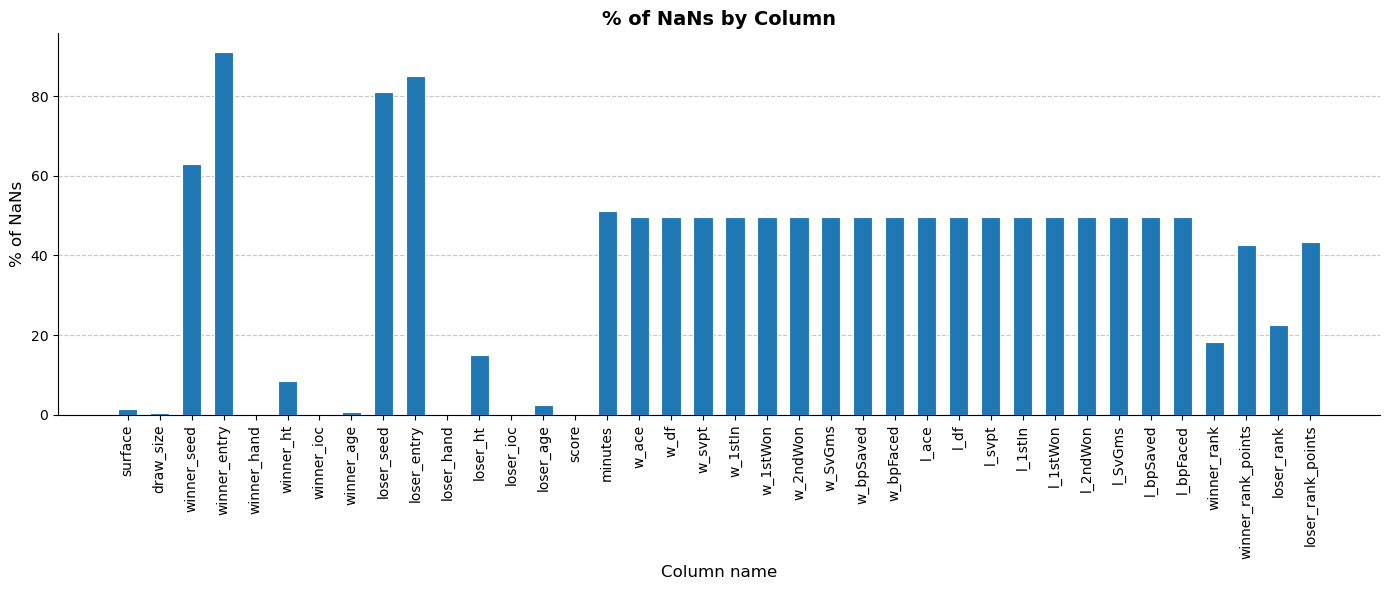

In [127]:
nan_percentage_plot(df_atp_matches)

In [ ]:
print(f"Duplicate rows: {df_atp_matches.duplicated().sum()}")

Duplicate rows: 0
Matches with no duration: 99891


### 1.2) Players

In [177]:
df_players = pd.read_csv('datasets/tennis_atp/atp_players.csv')

df_players['full_name'] = df_players['name_first']+ " " + df_players['name_last']
df_players['dob'] = pd.to_datetime(
    df_players['dob'].astype('Int64').astype(str),
    format='%Y%m%d',
    errors='coerce'
)
df_players.to_csv("datasets/clean_datasets/players_metadata.csv")
df_players.head()

/var/folders/k2/dk8bt59j05qbxf2_m65bzn380000gn/T/ipykernel_23485/2883038166.py:1: DtypeWarning: Columns (0: wikidata_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players = pd.read_csv('datasets/tennis_atp/atp_players.csv')


,player_id,name_first,name_last,hand,dob,ioc,height,wikidata_id,full_name
0,100001,Gardnar,Mulloy,R,1913-11-22,USA,185.0,Q54544,Gardnar Mulloy
1,100002,Pancho,Segura,R,1921-06-20,ECU,168.0,Q54581,Pancho Segura
2,100003,Frank,Sedgman,R,1927-10-02,AUS,180.0,Q962049,Frank Sedgman
3,100004,Giuseppe,Merlo,R,1927-10-11,ITA,NaN,Q1258752,Giuseppe Merlo
4,100005,Richard,Gonzalez,R,1928-05-09,USA,188.0,Q53554,Richard Gonzalez


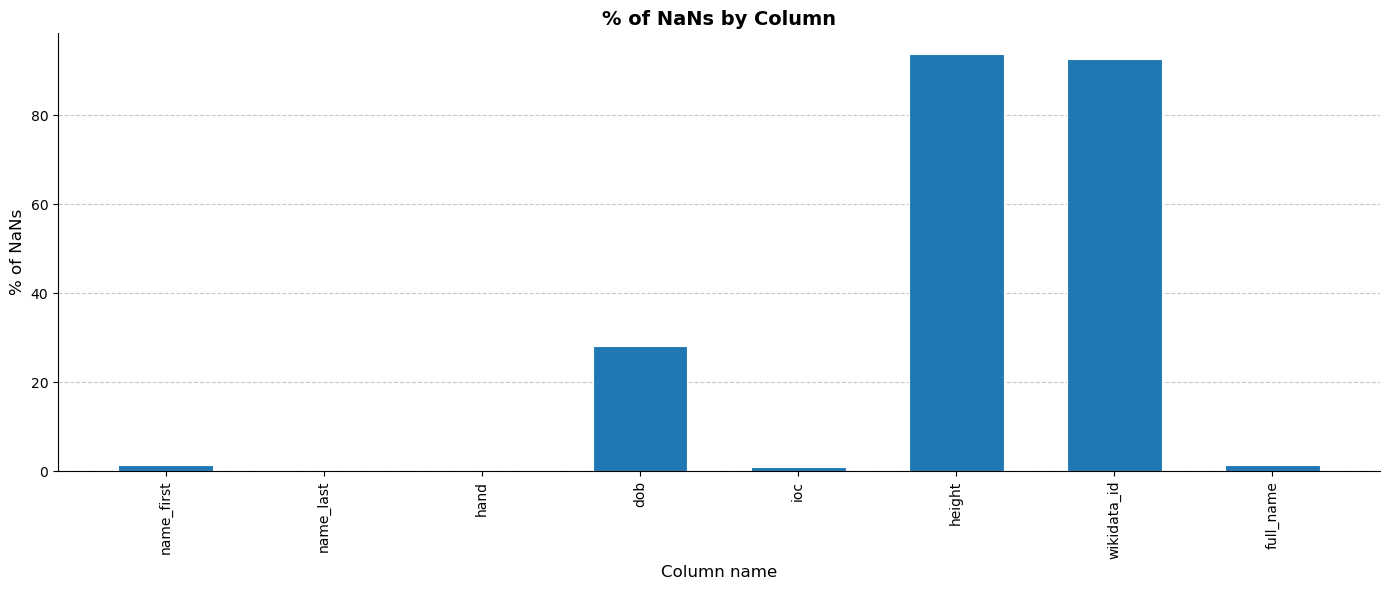

In [141]:
nan_percentage_plot(df_players)

### 1.3) Rankings

In [176]:
files = glob.glob('datasets/tennis_atp/atp_rankings_*.csv')

df_rankings = pd.concat(
    [pd.read_csv(f, parse_dates=['ranking_date'], date_format="%Y%m%d") for f in files],
    ignore_index=True)

df_rankings['ranking_date'] = pd.to_datetime(df_rankings['ranking_date'], errors='coerce')

df_rankings = df_rankings.merge(df_players[['full_name', 'player_id']],
                                left_on='player', right_on='player_id', how='left')
df_rankings.drop(columns=['player_id'], inplace=True)
df_rankings.to_csv("datasets/clean_datasets/all_rankings.csv")
df_rankings.head()

,ranking_date,rank,player,points,full_name
0,2000-01-10,1,101736,4135.0,Andre Agassi
1,2000-01-10,2,102338,2915.0,Yevgeny Kafelnikov
2,2000-01-10,3,101948,2419.0,Pete Sampras
3,2000-01-10,4,103017,2184.0,Nicolas Kiefer
4,2000-01-10,5,102856,2169.0,Gustavo Kuerten


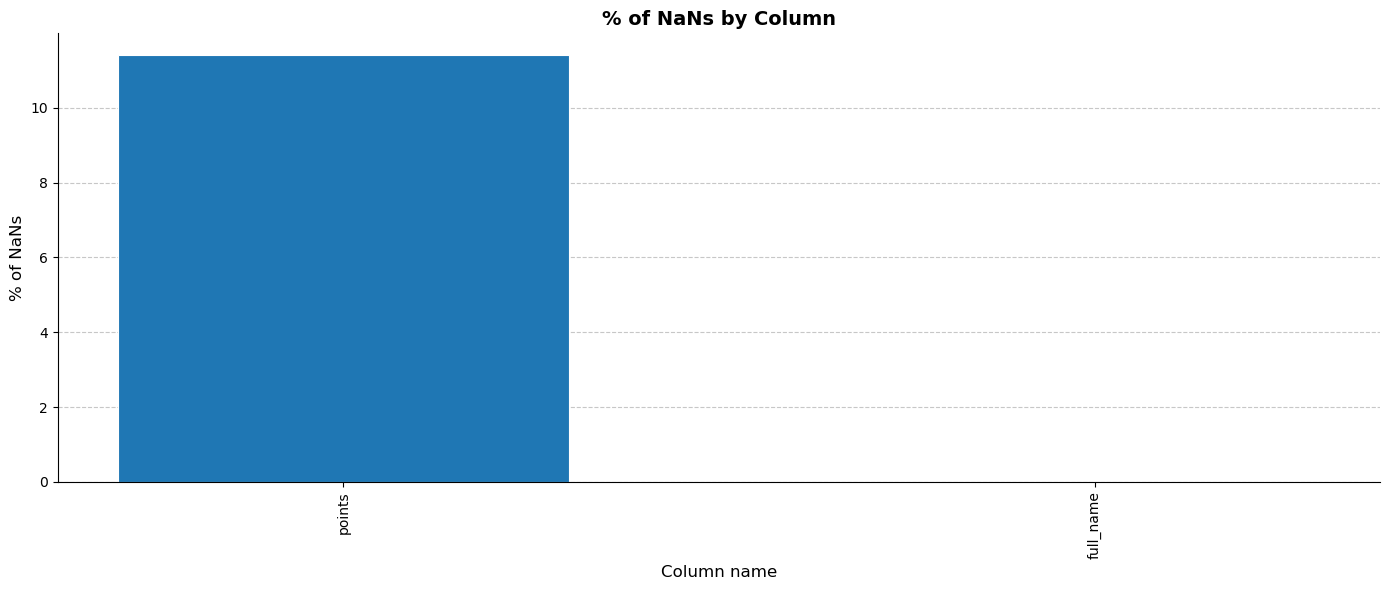

In [144]:
nan_percentage_plot(df_rankings)

### 1.4) Charting Stats

In [205]:
# Services
basic_service = pd.read_csv("datasets/charting_stats/charting-m-stats-ServeBasics.csv")

basic_service = basic_service[basic_service['row'] == 'Total']
basic_service = basic_service[['match_id', 'player','pts','pts_won','aces','unret','pts_won_lte_3_shots']]

service_direction = pd.read_csv("datasets/charting_stats/charting-m-stats-ServeDirection.csv")

service_direction = service_direction[service_direction['row'] == 'Total']
service_direction = service_direction[['match_id', 'player','deuce_wide','deuce_middle','deuce_t','ad_wide','ad_middle','ad_t', 'err_net','err_wide','err_deep','err_wide_deep']]

df_service = basic_service.merge(service_direction, on=['match_id','player'])

df_service.to_csv("datasets/clean_datasets/service_stats.csv")

In [206]:
# Returns

return_depth = pd.read_csv("datasets/charting_stats/charting-m-stats-ReturnDepth.csv")
return_depth = return_depth[return_depth['row'] == 'Total']
return_depth = return_depth.drop(columns=['row'])

return_outcome = pd.read_csv("datasets/charting_stats/charting-m-stats-ReturnOutcomes.csv")
return_outcome = return_outcome[return_outcome['row'] == 'Total']
return_outcome = return_outcome.drop(columns=['row'])

df_return = return_depth.merge(return_outcome, on=['match_id','player'])
df_return.to_csv("datasets/clean_datasets/return_stats.csv")

In [224]:
# Shots

shot_types = pd.read_csv("datasets/charting_stats/charting-m-stats-ShotTypes.csv")

shot_types_special = shot_types[shot_types['row'].isin(['Gs','Sl','Dr','Lo','Vo','Ov','Sw'])]
shot_types_special = shot_types_special[['match_id','player','row','shots']]
shot_types_special = shot_types_special.drop_duplicates(subset=['match_id', 'player', 'row'])
shot_types_special = shot_types_special.pivot(index=['match_id', 'player'], columns='row',values='shots')
shot_types_special.columns.name = None
shot_types_special = shot_types_special.reset_index().fillna(0)

shot_types_special.columns = (
    ['match_id', 'player'] + 
    [f'{col}_shots' for col in shot_types_special.columns[2:]]
)

shot_types = shot_types[shot_types['row'] == 'Total']
shot_types = shot_types[['match_id', 'player','shots','pt_ending','winners','induced_forced','unforced']]

shot_direction = pd.read_csv("datasets/charting_stats/charting-m-stats-ShotDirection.csv")
shot_direction = shot_direction[shot_direction['row'] == 'Total']
shot_direction = shot_direction[['match_id', 'player','crosscourt','down_middle','down_the_line']]

df_shots = shot_types.merge(shot_types_special, on=['match_id','player'])
df_shots = df_shots.merge(shot_direction, on=['match_id','player'])
df_shots.to_csv("datasets/clean_datasets/shots_stats.csv")


In [229]:
# Overview

stats_overview = pd.read_csv("datasets/charting_stats/charting-m-stats-Overview.csv")
stats_overview = stats_overview[stats_overview['set'] == 'Total']
stats_overview = stats_overview.drop(columns=['set','aces','serve_pts'])

stats_overview.to_csv("datasets/clean_datasets/overview_stats.csv")


In [233]:
# Net Points

net_points = pd.read_csv("datasets/charting_stats/charting-m-stats-NetPoints.csv")
net_points = net_points[net_points['row'] == 'NetPoints']
net_points.to_csv("datasets/clean_datasets/netpoints_stats.csv")

## 2) Basic Statistics

### 2.1) ATP Matches

In [145]:
unique_winners = set(df_atp_matches['winner_id'].unique())
unique_loser = set(df_atp_matches['loser_id'].unique())
unique_players = unique_winners.union(unique_loser)
upsets = df_atp_matches[df_atp_matches['loser_rank'] < df_atp_matches['winner_rank']]
youngest_winner = df_atp_matches.loc[df_atp_matches['winner_age'].idxmin(), ['winner_name','winner_age']].values
oldest_winner = df_atp_matches.loc[df_atp_matches['winner_age'].idxmax(), ['winner_name','winner_age']].values

print('------------ Stats ------------')
print(f"Total number of matches: {df_atp_matches.shape[0]}")
print(f"Total number of players: {len(unique_players)}")
print(f"Date of the first match: {df_atp_matches['tourney_date'].min().strftime('%Y-%m-%d')}")
print(f"Date of the last match: {df_atp_matches['tourney_date'].max().strftime('%Y-%m-%d')}")
print(f"Average duration of a match: {df_atp_matches['minutes'].mean():.2f} min")
print(f"Upsets percentage (Winner ranked lower than looser): {len(upsets)/len(df_atp_matches):.1%}")
print(f"Average winner age: {df_atp_matches['winner_age'].mean():.1f}")
print(f"Average loser age:  {df_atp_matches['loser_age'].mean():.1f}")
print(f"Youngest winner: {youngest_winner[0], int(youngest_winner[1])}")
print(f"Oldest winner:   {oldest_winner[0], int(oldest_winner[1])}")


------------ Stats ------------
Total number of matches: 194996
Total number of players: 7556
Date of the first match: 1967-12-28
Date of the last match: 2024-12-18
Average duration of a match: 104.31 min
Upsets percentage (Winner ranked lower than looser): 25.7%
Average winner age: 25.7
Average loser age:  25.7
Youngest winner: ('Laith Azzouni', 14)
Oldest winner:   ('Anthony Billington', 58)


### 2.2) Players

In [167]:
print('------------ Stats ------------')
print(f"Average player height: {df_players['height'].mean():.2f}")
print(f"Number of right-handed players: {len(df_players[df_players['hand']=='R'])}")
print(f"Number of left-handed players: {len(df_players[df_players['hand']=='L'])}")

------------ Stats ------------
Average player height: 183.48
Number of right-handed players: 16594
Number of left-handed players: 1566


### 2.3) Rankings

## 3) First plots

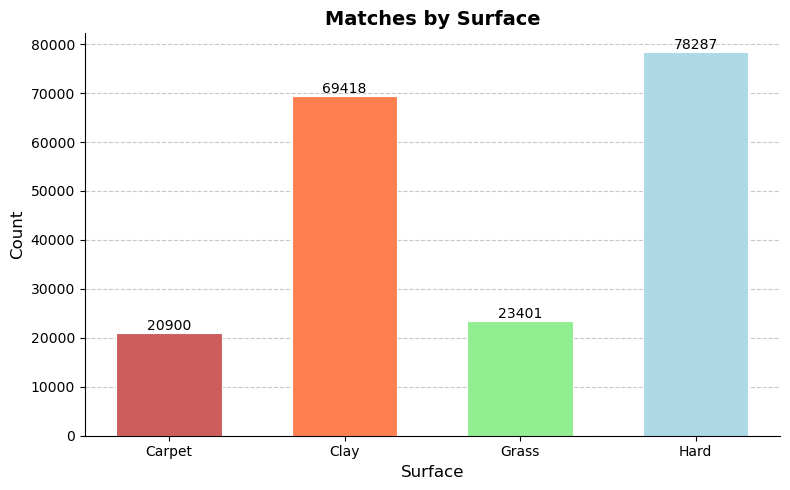

In [168]:
df_surfaces = df_atp_matches.groupby('surface').size().reset_index(name='count')
df_surfaces = df_surfaces[df_surfaces['surface'].isin(['Clay', 'Hard', 'Grass', 'Carpet'])]

fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Clay': 'coral', 'Hard': 'lightblue', 'Grass': 'lightgreen', 'Carpet': 'indianred'}

ax.bar(
    df_surfaces['surface'],
    df_surfaces['count'],
    color=[colors[s] for s in df_surfaces['surface']],
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_xlabel('Surface', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Matches by Surface', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

/var/folders/k2/dk8bt59j05qbxf2_m65bzn380000gn/T/ipykernel_23485/4202996473.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Accent', len(df_tourney_level))


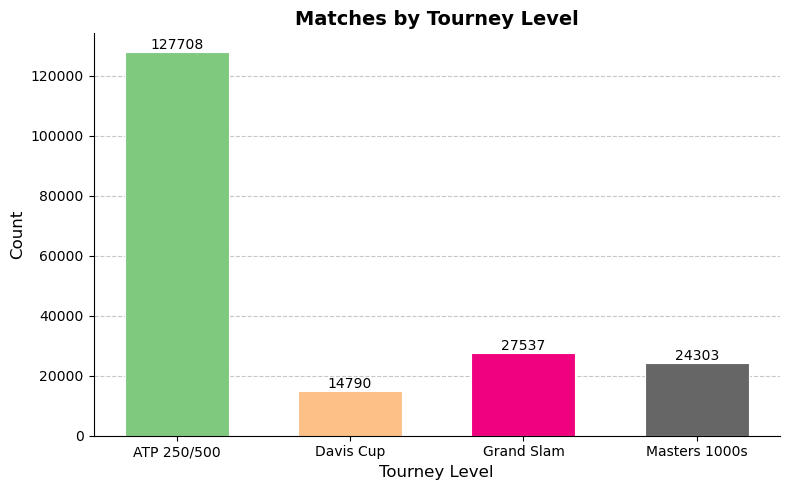

In [170]:
df_tourney_level = df_atp_matches.groupby('tourney_level').size().reset_index(name='count')
df_tourney_level = df_tourney_level[df_tourney_level['tourney_level'].isin(['S','C','A','G','M','D'])]

level_names = {
    'A': 'ATP 250/500',
    'G': 'Grand Slam',
    'M': 'Masters 1000s',
    'D': 'Davis Cup'
}

df_tourney_level['tourney_level'] = df_tourney_level['tourney_level'].map(level_names)

fig, ax = plt.subplots(figsize=(8, 5))

cmap = cm.get_cmap('Accent', len(df_tourney_level))
colors = [cmap(i) for i in range(len(df_tourney_level))]

ax.bar(
    df_tourney_level['tourney_level'],
    df_tourney_level['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_xlabel('Tourney Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Matches by Tourney Level', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Rankings

/var/folders/k2/dk8bt59j05qbxf2_m65bzn380000gn/T/ipykernel_23485/1562862632.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Paired', len(top_players_df))


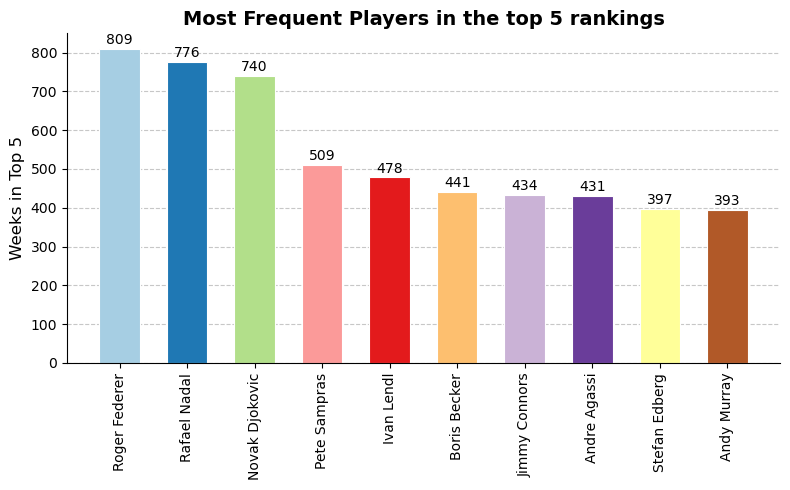

In [174]:
df_rankings_top5 = df_rankings[df_rankings['rank'] <= 5]

top_players_df = (df_rankings_top5['full_name']
               .value_counts()
               .head(10)
               .reset_index(name='count'))


fig, ax = plt.subplots(figsize=(8, 5))

cmap = cm.get_cmap('Paired', len(top_players_df))
colors = [cmap(i) for i in range(len(top_players_df))]

ax.bar(
    top_players_df['full_name'],
    top_players_df['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_ylabel('Weeks in Top 5', fontsize=12)
ax.set_title('Most Frequent Players in the top 5 rankings', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

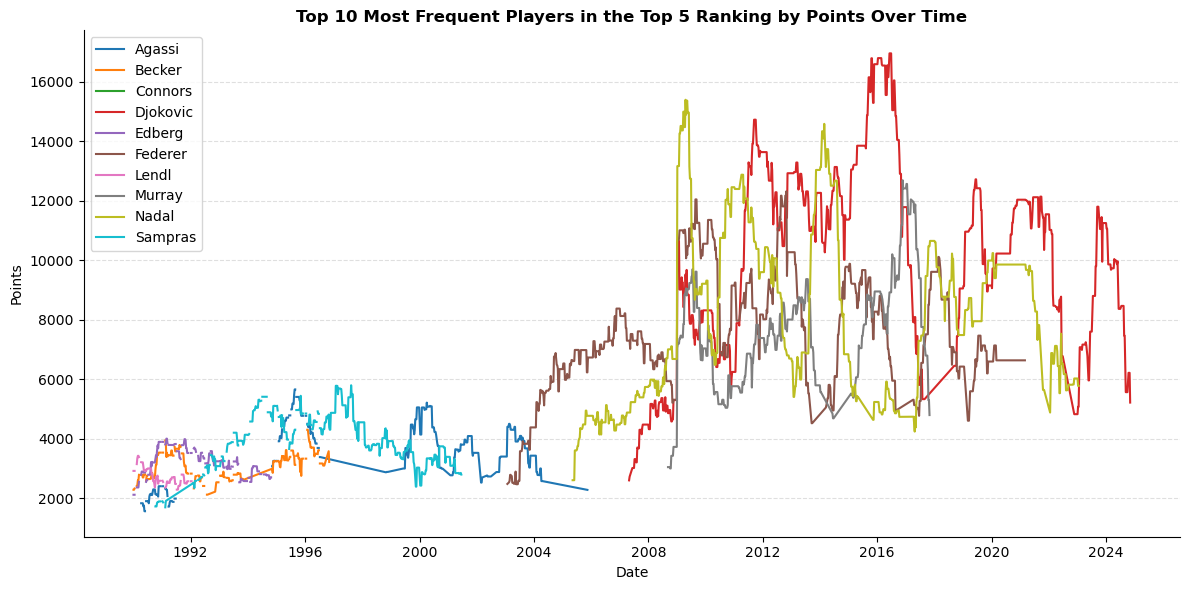

In [82]:


top_players = top_players_df['name_last']

df_plot = df_rankings_top5[df_rankings_top5['name_last'].isin(top_players)]

fig, ax = plt.subplots(figsize=(12, 6))

cmap = plt.colormaps['tab10'].resampled(len(top_players))

for i, (name, group) in enumerate(df_plot.groupby('name_last')):
    group = group.sort_values('ranking_date')
    ax.plot(group['ranking_date'], group['points'], label=name, color=cmap(i), linewidth=1.5)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel('Date')
ax.set_ylabel('Points')
ax.legend()
ax.set_title('Top 10 Most Frequent Players in the Top 5 Ranking by Points Over Time', fontweight='bold')

plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()

# Charting Pre

charting-m-stats-ReturnDepth.csv